In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Part (a): Turning points and momentum**

**Part (i):**

At turning points $\xi' = 0$.
$$\varepsilon = \frac{1}{2}(\xi')^2 + V(\xi) \tag{dimensionless energy}$$
$$\implies \varepsilon = V(\xi) = \xi^2 - 1 \\[5 pt]
\implies \xi_\pm = \pm \sqrt{1 + \varepsilon} \tag{a.1}$$

**Part (ii):**
$$\varepsilon = \Pi^2(\xi) + V(\xi) \\[5 pt]
\implies \Pi(\xi) = \pm \sqrt{\varepsilon - V(\xi)} \tag{a.2}$$

**Part (iii):**

From (a.1), the turning points are at $\xi_\pm = \pm \sqrt{1 + \varepsilon}$. Substituting into (a.2):
$$\Pi(\xi_\pm) = \pm \sqrt{\varepsilon - (\xi^2_\pm - 1)} = 0$$

## **Part (b): Action Integral**

**Part (i):**

Substituting (a.2):
$$S(\varepsilon) = \int_{-\sqrt{1+\varepsilon}}^{\sqrt{1+\varepsilon}} \sqrt{(1+\varepsilon) - \xi^2}\, d\xi \tag{b.1}$$

**Part (ii):**
$$\xi = \sqrt{1+\varepsilon} \,sin\,\theta \\[5 pt]
\implies d\xi = \sqrt{1+\varepsilon} \, cos\,\theta \,d\theta$$

$\xi = -\sqrt{1+\varepsilon} \implies sin\,\theta = -1 \implies \theta = -\frac{\pi}{2} \\
\xi = \sqrt{1+\varepsilon} \implies sin\,\theta = 1 \implies \theta = \frac{\pi}{2}$

Substituting this into (b.1):
$$S(\varepsilon) = \int_{-\frac{\pi}{2}}^{\frac{\pi}{2}} \sqrt{(1+\varepsilon)-(1+\varepsilon)\,sin^2\theta}\,\sqrt{1+\varepsilon}\,cos\,\theta\,d\theta \\
= 2\int_0^{\frac{\pi}{2}} (1+\varepsilon)\, cos^2\theta\,d\theta \\
= (1+\varepsilon) \int 1+cos\,2\theta\,d\theta \\
\implies S(\varepsilon) = \frac{\pi}{2}(1+\varepsilon) \tag{b.2}$$

**Part (iii):**

For integration:
$$f(\varepsilon, \xi) = \sqrt{(1+\varepsilon) - \xi^2} \\[5 pt]
S(\varepsilon) = \int_{-\sqrt{1+\varepsilon}}^{\sqrt{1+\varepsilon}} f(\varepsilon, \xi) \, d\xi$$

In [11]:
# Simpson's 1/3 Method
def S_numerical(f, E, N, lower, upper):
	h = (upper-lower)/N
	hs = np.linspace(lower, upper, N+1)
	fs = np.array(f(E, hs))

	s = (h/3)*(fs[0] + fs[-1] + 4*sum(fs[1:-1:2]) + 2*sum(fs[2:-2:2]))
	return s

# Integrand
def f(E, xi):
	return np.sqrt(abs((1+E)-xi**2))
# Theoretical integral
def S_theory(E):
     return np.pi/2*(1+E)

# Parameters
Es = np.array([-0.8, -0.5, -0.2])
N = 200
uppers, lowers = np.sqrt(1+Es), -np.sqrt(1+Es)

# Printing data
print("Energy S_num S_theory")
for i in range(len(Es)):
     S_num = S_numerical(f, Es[i], N, lowers[i], uppers[i])
     S_th = S_theory(Es[i])
     
     print(f"{Es[i]}  {S_num: 0.3f} {S_th: 0.3f}")

Energy S_num S_theory
-0.8   0.314  0.314
-0.5   0.785  0.785
-0.2   1.256  1.257


## **Part (c): WKB energy eigenvalues**

**Part (i):**
$$\Lambda S(\varepsilon_n) = \left(n+\frac{1}{2}\right)\pi \\[5 pt]
\implies (1+\varepsilon_n)\frac{\pi}{2} = \frac{1}{\Lambda}\left(n+\frac{1}{2}\right)\pi \tag{from b.2}$$
$$\implies \varepsilon_n = \frac{2n+1}{\Lambda}-1$$

**Parts (ii) and (iii):**
$$\varepsilon_n = \frac{2n+1}{6}-1 = \frac{2n-5}{6}$$

For bound states, $-1 < \varepsilon < 0$. Checking for different n:

$n = 0 \rightarrow \varepsilon_0 = -\frac{5}{6} \\[5 pt]
n = 1 \rightarrow \varepsilon_1 = -\frac{1}{2} \\[5 pt]
n = 2 \rightarrow \varepsilon_2 = -\frac{1}{6}$

These are the 3 bound-state energies.

## **Part (d): Plots**

**Parts (i), (i) and (iii):**

In [9]:
# Dimensionless Potential
def dim_V(xi):
    if abs(xi) <= 1:
        return xi**2-1
    else:
        return 0
# Turning points
def turning_points(E):
    return (-np.sqrt(1+E), np.sqrt(1+E))

# Parameters    
xii, xif = -1.2, 1.2
dxi = 1e-2
N = int((xif-xii)/dxi)
xis = np.linspace(xii, xif, N)
Vs = [dim_V(xi) for xi in xis]
E_bound = [-5/6, -1/2, -1/6]

Plotting

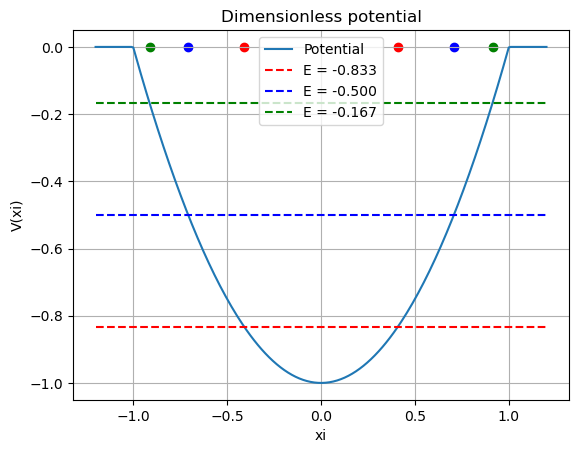

In [ ]:
# Dimensionless potential
plt.plot(xis, Vs, label="Potential")
colors = ["red", "blue", "green"]

# Bound-state energies and turning points
for i in range(len(E_bound)):
    plt.plot([xii, xif], [E_bound[i], E_bound[i]], '--', color = colors[i], label = f"E = {E_bound[i]: 0.3f}")
    plt.scatter(turning_points(E_bound[i]), [0, 0], color = colors[i])

plt.xlabel("xi")
plt.ylabel("V(xi)")
plt.title("Dimensionless potential")

plt.legend()
plt.grid()
plt.show()

**Part (iv):**

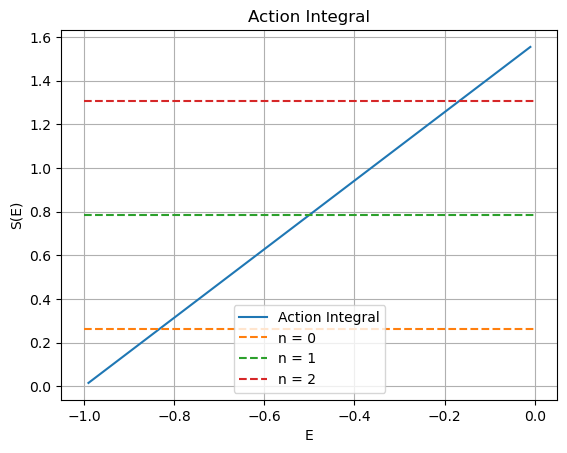

In [14]:
# Parameters
Ei, Ef = -1, 0
dE = 1e-2
N = int((Ef-Ei)/dE)
Es = np.linspace(Ei+dE, Ef-dE, N)
Ss = S_theory(Es)

# Quantisation of S(E)
Lambda = 6
ns = [0, 1, 2]
quants = [(n+1/2)*np.pi/Lambda for n in ns]

# Plotting
plt.plot(Es, Ss, label = "Action Integral")
for i in range(len(ns)):
    plt.plot([Ei, Ef], [quants[i], quants[i]], '--', label = f"n = {ns[i]}")
    
plt.xlabel("E")
plt.ylabel("S(E)")
plt.title("Action Integral")
plt.legend()
plt.grid()
plt.show()